In [129]:
import re
import zipfile
import pandas as pd
from pathlib import Path
from itertools import combinations
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
import numpy as np
import random
from __future__ import annotations
import math
import itertools
from collections import defaultdict
from typing import Iterable



In [19]:
def kaggle_data_handler(kaggle_url, csv_index=0):
    match = re.search(r"kaggle\.com/datasets/([^/]+)/([^/?#]+)", kaggle_url)
    if not match:
        raise ValueError(f"Could not parse Kaggle dataset URL: {kaggle_url}")

    owner, slug = match.group(1), match.group(2)

    try:
        download_dir = Path(__file__).parent / "data"
    except NameError:
        download_dir = Path.cwd() / "data"

    existing_csvs = sorted(download_dir.glob("*.csv")) if download_dir.exists() else []

    if not existing_csvs:
        from kaggle.api.kaggle_api_extended import KaggleApi
        api = KaggleApi()
        api.authenticate()
        download_dir.mkdir(parents=True, exist_ok=True)
        api.dataset_download_files(f"{owner}/{slug}", path=str(download_dir), unzip=False, quiet=False)

        for z in download_dir.glob("*.zip"):
            with zipfile.ZipFile(z, "r") as zf:
                zf.extractall(download_dir)
            z.unlink()

        existing_csvs = sorted(download_dir.glob("*.csv"))

    return pd.read_csv(existing_csvs[csv_index])

In [20]:
kaggle_link = 'https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows'

In [21]:
df = kaggle_data_handler(kaggle_link)

Dataset URL: https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows


100%|██████████| 175k/175k [00:00<00:00, 658kB/s]

In [23]:
df.describe()

,IMDB_Rating,Meta_score,No_of_Votes
count,1000.000000,843.000000,1.000000e+03
mean,7.949300,77.971530,2.736929e+05
std,0.275491,12.376099,3.273727e+05
min,7.600000,28.000000,2.508800e+04
25%,7.700000,70.000000,5.552625e+04
50%,7.900000,79.000000,1.385485e+05
75%,8.100000,87.000000,3.741612e+05
max,9.300000,100.000000,2.343110e+06


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   str    
 1   Series_Title   1000 non-null   str    
 2   Released_Year  1000 non-null   str    
 3   Certificate    899 non-null    str    
 4   Runtime        1000 non-null   str    
 5   Genre          1000 non-null   str    
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   str    
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   str    
 10  Star1          1000 non-null   str    
 11  Star2          1000 non-null   str    
 12  Star3          1000 non-null   str    
 13  Star4          1000 non-null   str    
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    str    
dtypes: float64(2), int64(1), str(13)
memory usage: 125.1 KB


In [25]:
df.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='str')

### DEFINING THE BASKETS & ITEMS

In [28]:
baskets = df[["Star1","Star2","Star3","Star4"]].values.tolist()
baskets = [set(row) for row in baskets]

In [29]:
baskets

[{'Bob Gunton', 'Morgan Freeman', 'Tim Robbins', 'William Sadler'},
 {'Al Pacino', 'Diane Keaton', 'James Caan', 'Marlon Brando'},
 {'Aaron Eckhart', 'Christian Bale', 'Heath Ledger', 'Michael Caine'},
 {'Al Pacino', 'Diane Keaton', 'Robert De Niro', 'Robert Duvall'},
 {'Henry Fonda', 'John Fiedler', 'Lee J. Cobb', 'Martin Balsam'},
 {'Elijah Wood', 'Ian McKellen', 'Orlando Bloom', 'Viggo Mortensen'},
 {'Bruce Willis', 'John Travolta', 'Samuel L. Jackson', 'Uma Thurman'},
 {'Ben Kingsley', 'Caroline Goodall', 'Liam Neeson', 'Ralph Fiennes'},
 {'Elliot Page', 'Joseph Gordon-Levitt', 'Ken Watanabe', 'Leonardo DiCaprio'},
 {'Brad Pitt', 'Edward Norton', 'Meat Loaf', 'Zach Grenier'},
 {'Elijah Wood', 'Ian McKellen', 'Orlando Bloom', 'Sean Bean'},
 {'Gary Sinise', 'Robin Wright', 'Sally Field', 'Tom Hanks'},
 {'Aldo Giuffrè', 'Clint Eastwood', 'Eli Wallach', 'Lee Van Cleef'},
 {'Elijah Wood', 'Ian McKellen', 'Orlando Bloom', 'Viggo Mortensen'},
 {'Carrie-Anne Moss', 'Keanu Reeves', 'Laurenc

In [123]:
def plot_cooccurrence_network(doubleton_support, singleton_support, min_support=3, top_n=30):
    """
    doubleton_support: dict {(item1, item2): support}
    singleton_support: dict {item: support}
    min_support: minimum edge support to display
    top_n: only include top N actors by singleton support
    """
    # Restrict to top N actors
    top_actors = set(
        sorted(singleton_support, key=singleton_support.get, reverse=True)[:top_n]
    )

    G = nx.Graph()

    # Add edges for frequent pairs among top actors
    for (actor1, actor2), support in doubleton_support.items():
        if support >= min_support and actor1 in top_actors and actor2 in top_actors:
            G.add_edge(actor1, actor2, weight=support)

    # Add isolated nodes for top actors with no qualifying pairs
    for actor in top_actors:
        if actor not in G:
            G.add_node(actor)

    node_sizes  = [singleton_support.get(n, 1) * 80 for n in G.nodes()]
    edge_weights = [G[u][v]["weight"] for u, v in G.edges()]

    pos = nx.spring_layout(G, seed=42, k=1.5)

    fig, ax = plt.subplots(figsize=(14, 10))

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="steelblue", alpha=0.8, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)
    nx.draw_networkx_edges(
        G, pos,
        width=[w * 0.5 for w in edge_weights],
        edge_color=edge_weights,
        edge_cmap=plt.cm.Oranges,
        alpha=0.7,
        ax=ax
    )

    ax.set_title(f"Actor Co-occurrence Network (top {top_n} actors, min support={min_support})")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

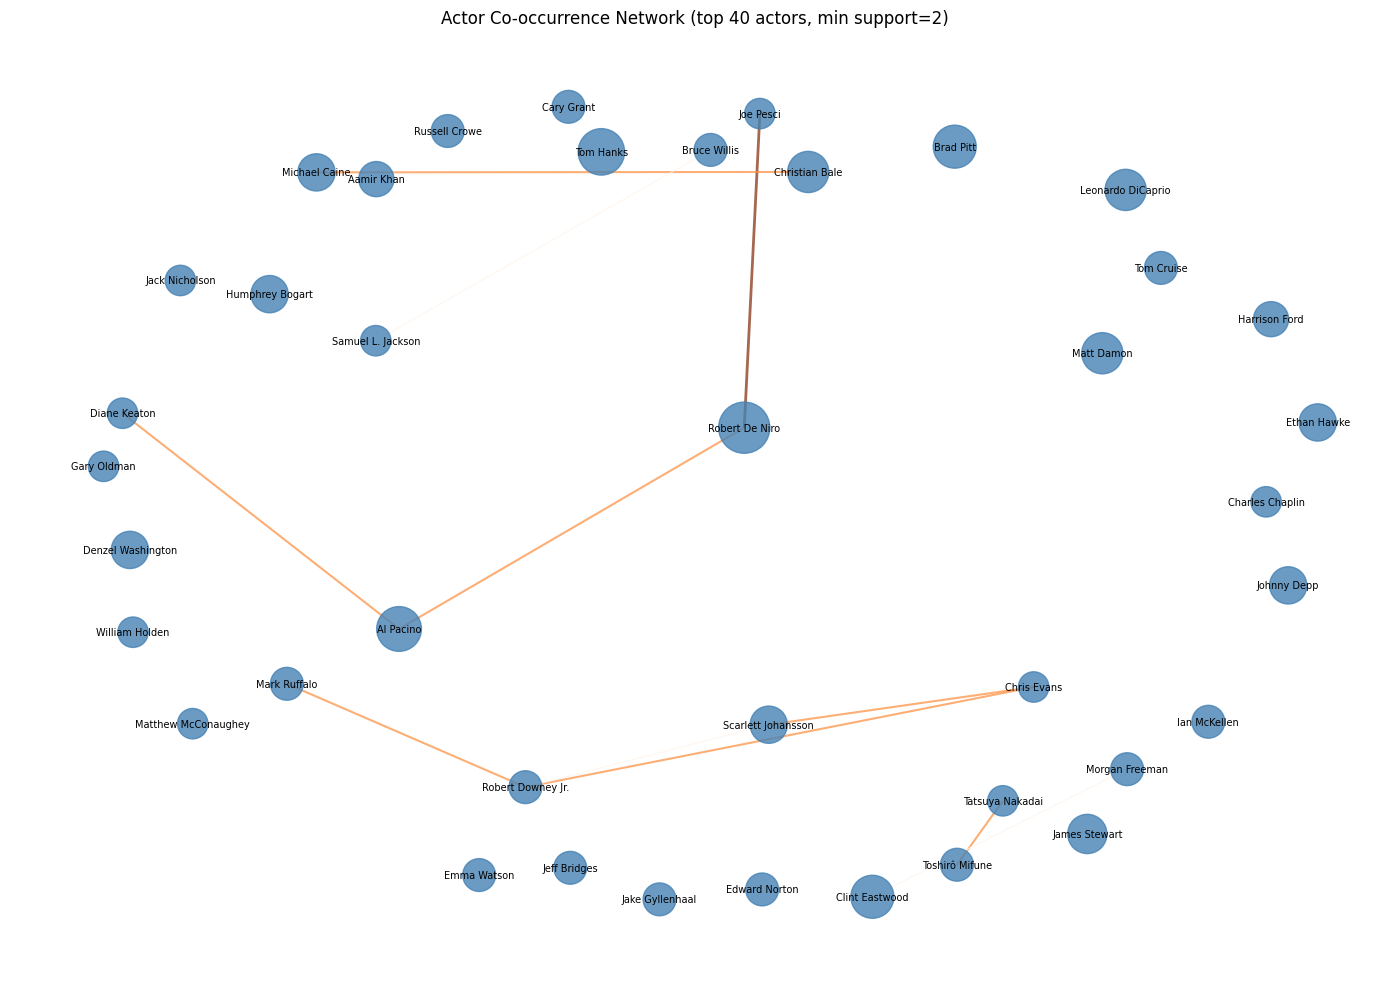

In [126]:
plot_cooccurrence_network(doubleton_support, singleton_support, min_support=2, top_n=40)

### SUPPORT CALCULATION FOR SINGLETONS

In [46]:
singleton_support = defaultdict(int)

for basket in baskets:
    for item in basket:
        singleton_support[item] += 1

singleton_support = dict(sorted(singleton_support.items(), key=lambda x: x[1], reverse=True))

print("Singleton Support:")
for item, support in singleton_support.items():
    print(f"  {item}: {support}")

Singleton Support:
  Robert De Niro: 17
  Tom Hanks: 14
  Al Pacino: 13
  Brad Pitt: 12
  Clint Eastwood: 12
  Christian Bale: 11
  Leonardo DiCaprio: 11
  Matt Damon: 11
  James Stewart: 10
  Michael Caine: 9
  Scarlett Johansson: 9
  Humphrey Bogart: 9
  Ethan Hawke: 9
  Johnny Depp: 9
  Denzel Washington: 9
  Harrison Ford: 8
  Aamir Khan: 8
  Morgan Freeman: 7
  Ian McKellen: 7
  Bruce Willis: 7
  Edward Norton: 7
  Toshirô Mifune: 7
  Russell Crowe: 7
  Mark Ruffalo: 7
  Robert Downey Jr.: 7
  Cary Grant: 7
  Jake Gyllenhaal: 7
  Emma Watson: 7
  Jeff Bridges: 7
  Tom Cruise: 7
  Diane Keaton: 6
  Samuel L. Jackson: 6
  Joe Pesci: 6
  Jack Nicholson: 6
  Matthew McConaughey: 6
  Tatsuya Nakadai: 6
  Gary Oldman: 6
  Charles Chaplin: 6
  Chris Evans: 6
  William Holden: 6
  Paul Newman: 6
  Shah Rukh Khan: 6
  Ed Harris: 6
  Christopher Plummer: 6
  Gene Hackman: 6
  Rachel McAdams: 6
  Rupert Grint: 6
  Daniel Radcliffe: 6
  Philip Seymour Hoffman: 6
  Josh Brolin: 6
  Julianne Mo

### SUPPORT CALCULATION DOUBLETONS

In [48]:
doubleton_support = defaultdict(int)

for basket in baskets:
    for pair in combinations(sorted(basket), 2):
        doubleton_support[pair] += 1

doubleton_support = dict(sorted(doubleton_support.items(), key=lambda x: x[1], reverse=True))

print("Doubleton Support:")
for pair, support in doubleton_support.items():
    print(f"  {pair}: {support}")

Doubleton Support:
  ('Daniel Radcliffe', 'Rupert Grint'): 6
  ('Daniel Radcliffe', 'Emma Watson'): 5
  ('Emma Watson', 'Rupert Grint'): 5
  ('Joe Pesci', 'Robert De Niro'): 4
  ('Tim Allen', 'Tom Hanks'): 4
  ('Al Pacino', 'Diane Keaton'): 3
  ('Christian Bale', 'Michael Caine'): 3
  ('Al Pacino', 'Robert De Niro'): 3
  ('Elijah Wood', 'Ian McKellen'): 3
  ('Elijah Wood', 'Orlando Bloom'): 3
  ('Ian McKellen', 'Orlando Bloom'): 3
  ('Carrie Fisher', 'Harrison Ford'): 3
  ('Carrie Fisher', 'Mark Hamill'): 3
  ('Harrison Ford', 'Mark Hamill'): 3
  ('Takashi Shimura', 'Toshirô Mifune'): 3
  ('Chris Evans', 'Joe Russo'): 3
  ('Chris Evans', 'Robert Downey Jr.'): 3
  ('Joe Russo', 'Robert Downey Jr.'): 3
  ('Mark Ruffalo', 'Robert Downey Jr.'): 3
  ('Tatsuya Nakadai', 'Toshirô Mifune'): 3
  ('Ethan Hawke', 'Julie Delpy'): 3
  ('Chris Evans', 'Scarlett Johansson'): 3
  ('Diane Keaton', 'Woody Allen'): 3
  ('Humphrey Bogart', 'Lauren Bacall'): 3
  ('Ethan Coen', 'John Turturro'): 3
  ('Elija

### CONFIDENCE CALCULATION

In [67]:
def confidence(lhs, rhs, baskets, verbose=True):
    lhs = set(lhs)
    rhs = set(rhs)
    union = lhs | rhs

    support_lhs   = sum(1 for b in baskets if lhs.issubset(b))
    support_union = sum(1 for b in baskets if union.issubset(b))

    if support_lhs == 0:
        return None

    conf = support_union / support_lhs

    if verbose:
        print(f"  support({lhs}) = {support_lhs}")
        print(f"  support({lhs | rhs}) = {support_union}")
        print(f"  confidence({lhs} → {rhs}) = {support_union}/{support_lhs} = {conf:.4f}")

    return conf

In [68]:
confidence({"Christian Bale"}, {"Robert De Niro"}, baskets)


  support({'Christian Bale'}) = 11
  support({'Christian Bale', 'Robert De Niro'}) = 0
  confidence({'Christian Bale'} → {'Robert De Niro'}) = 0/11 = 0.0000


0.0

Interpretation : Christian Bale appears in 11 different movies. But Robert De Niro does not appear in any movie that Christian Bale appeared. Therefore, Confidence score is 0/11 = 0

In [69]:
confidence({"Emma Watson"}, {"Rupert Grint"}, baskets)


  support({'Emma Watson'}) = 7
  support({'Rupert Grint', 'Emma Watson'}) = 5
  confidence({'Emma Watson'} → {'Rupert Grint'}) = 5/7 = 0.7143


0.7142857142857143

Interpretation : Emma Watson appears in 7 diferent movies. Rubert Grint appears in 5 movies among those 7 movies that Emma Watson appeared in. Therefore, confidence level is 5/7 = 0.71

In [70]:
confidence({"Orlando Bloom"}, {"Elijah Wood"}, baskets)


  support({'Orlando Bloom'}) = 4
  support({'Orlando Bloom', 'Elijah Wood'}) = 3
  confidence({'Orlando Bloom'} → {'Elijah Wood'}) = 3/4 = 0.7500


0.75

Interpretation : Orlando Bloom appears in 4 movies. Elija Wood appears in 3 movies among those 4 movies that Orlando Bloom appeared in.Therefore, confidence level is 3/4 = 0.75

### INTEREST CALCULATION

In [71]:
def interest(lhs, rhs, baskets):
    """
    lhs: list or set of items (left-hand side)
    rhs: list or set of items (right-hand side)
    """
    rhs = set(rhs)

    conf = confidence(lhs, rhs, baskets)

    if conf is None:
        return None

    support_rhs = sum(1 for b in baskets if rhs.issubset(b))
    prob_rhs = support_rhs / len(baskets)

    interest_score = conf - prob_rhs

    print(f"  P({rhs}) = {support_rhs}/{len(baskets)} = {prob_rhs:.4f}")
    print(f"  interest({set(lhs)} → {rhs}) = {conf:.4f} - {prob_rhs:.4f} = {interest_score:.4f}")
    return interest_score

In [72]:
interest({"Orlando Bloom"}, {"Elijah Wood"}, baskets)

  support({'Orlando Bloom'}) = 4
  support({'Orlando Bloom', 'Elijah Wood'}) = 3
  confidence({'Orlando Bloom'} → {'Elijah Wood'}) = 3/4 = 0.7500
  P({'Elijah Wood'}) = 3/1000 = 0.0030
  interest({'Orlando Bloom'} → {'Elijah Wood'}) = 0.7500 - 0.0030 = 0.7470


0.747

Confidence level is 0.75 for Orlando Bloom -> Elijah Wood.

Elija Wood appears in 3 movies among all 1000 movies in dataset -> 3/1000 = 0.003

Therefore, interest level is ;

0.75 - 0.003 = 0.747

So, presence of Orlando Bloom encourages Elijah Wood to be in that movie.

### FINDING ASSOCIATION RULES

In [73]:
def find_association_rules(baskets, singleton_support, top_support_pct, min_confidence_pct=50):
    """
    baskets: list of sets
    singleton_support: dict {item: support}
    top_support_pct: top n% of items by support (e.g. 20 for top 20%)
    min_confidence_pct: minimum confidence threshold in percentage (default=50)
    """
    min_confidence = min_confidence_pct / 100

    sorted_items = sorted(singleton_support.items(), key=lambda x: x[1], reverse=True)
    top_n = max(1, int(len(sorted_items) * top_support_pct / 100))
    frequent_singletons = {item for item, sup in sorted_items[:top_n]}

    rules = []

    for item in frequent_singletons:
        for other_item in frequent_singletons:
            if item == other_item:
                continue

            conf = confidence({item}, {other_item}, baskets, verbose=False)
            if conf is not None and conf >= min_confidence:
                rules.append({
                    "lhs": item,
                    "rhs": other_item,
                    "support": singleton_support[item],
                    "confidence": conf
                })

    rules = sorted(rules, key=lambda x: x["confidence"], reverse=True)

    print(f"Found {len(rules)} association rules | top {top_support_pct}% support ({top_n} items) | confidence >= {min_confidence_pct}%\n")
    for rule in rules:
        print(f"  {rule['lhs']} → {rule['rhs']}  |  support: {rule['support']}  |  confidence: {rule['confidence']*100:.2f}%")

    return rules

In [76]:
rules = find_association_rules(baskets, singleton_support, top_support_pct=1, min_confidence_pct=20)

Found 8 association rules | top 1% support (27 items) | confidence >= 20%

  Mark Ruffalo → Robert Downey Jr.  |  support: 7  |  confidence: 42.86%
  Robert Downey Jr. → Mark Ruffalo  |  support: 7  |  confidence: 42.86%
  Michael Caine → Christian Bale  |  support: 9  |  confidence: 33.33%
  Morgan Freeman → Clint Eastwood  |  support: 7  |  confidence: 28.57%
  Robert Downey Jr. → Scarlett Johansson  |  support: 7  |  confidence: 28.57%
  Christian Bale → Michael Caine  |  support: 11  |  confidence: 27.27%
  Al Pacino → Robert De Niro  |  support: 13  |  confidence: 23.08%
  Scarlett Johansson → Robert Downey Jr.  |  support: 9  |  confidence: 22.22%


In [121]:
def plot_association_rules_scatter(rules_df, baskets, singleton_support):
    """
    rules_df: DataFrame output from apriori()
    baskets: list of sets
    singleton_support: dict {item: support}
    """
    total_baskets = len(baskets)

    df = rules_df.copy()

    # Compute interest = confidence - P(consequent)
    df["interest"] = df.apply(
        lambda row: (row["confidence"] / 100) -
                    (singleton_support.get(list(row["consequents"])[0], 0) / total_baskets),
        axis=1
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    scatter = ax.scatter(
        df["support"],
        df["confidence"],
        c=df["interest"],
        s=80,
        cmap="RdYlGn",
        alpha=0.7,
        edgecolors="grey",
        linewidths=0.5
    )

    plt.colorbar(scatter, ax=ax, label="Interest")
    ax.set_xlabel("Support")
    ax.set_ylabel("Confidence (%)")
    ax.set_title("Association Rules: Support vs Confidence (color = Interest)")
    ax.axhline(y=50, color="red", linestyle="--", linewidth=0.8, label="50% confidence threshold")
    ax.legend()
    plt.tight_layout()
    plt.show()

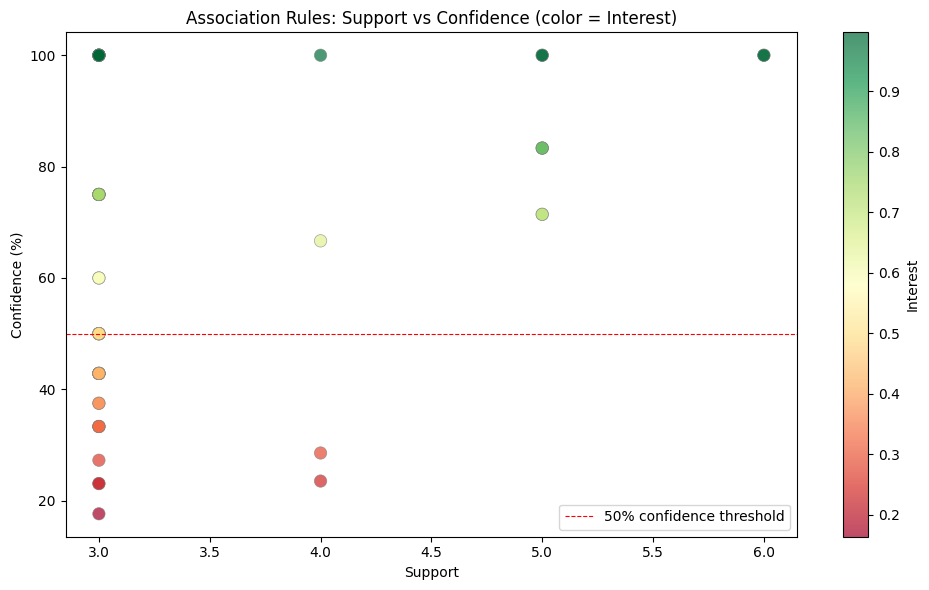

In [122]:
plot_association_rules_scatter(frequent_itemsets, baskets, singleton_support)

### THE TRIANGULAR MATRIX METHOD & TRIPLES METHOD

#### THE TRIANGULAR MATRIX METHOD


When counting pair occurrences across baskets, a naive 2D array `a[i][j]` wastes half its space — both `a[i][j]` and `a[j][i]` would store the same pair `{i, j}`.

**Goal:** Store counts for all pairs $\{i, j\}$ where $i < j$, using a single flat 1D array with no wasted slots.


For $n$ items, only the **upper triangle** of the matrix is needed:

|       | j=1 | j=2     | j=3     | j=4     |
|-------|-----|---------|---------|---------|
| **i=1** | —   | {1, 2}  | {1, 3}  | {1, 4}  |
| **i=2** | —   | —       | {2, 3}  | {2, 4}  |
| **i=3** | —   | —       | —       | {3, 4}  |
| **i=4** | —   | —       | —       | —       |

These 6 pairs (for $n = 4$) are stored **in lexicographic order** in a 1D array `a[k]`:

| k    | 1      | 2      | 3      | 4      | 5      | 6      |
|------|--------|--------|--------|--------|--------|--------|
| pair | {1, 2} | {1, 3} | {1, 4} | {2, 3} | {2, 4} | {3, 4} |

---

## Index Formula

To look up the count for pair $\{i, j\}$ (with $i < j$) directly:

$$k = (i - 1)\!\left(n - \frac{i}{2}\right) + j - i$$

---

## Space Complexity

Total pairs stored $= \binom{n}{2} = \frac{n(n-1)}{2}$

At 4 bytes per integer, total memory required:

$$\text{Memory} = 2n^2 \text{ bytes} \approx \frac{n^2}{2} \times 4 \text{ bytes}$$

**Example:** With $n = 32{,}000$ items and 2 GB of RAM:
- We need $2n^2$ bytes $\leq 2^{31}$ bytes
- This gives $n \leq 2^{15} \approx 32{,}768$ items maximum

In [78]:
def triangular_matrix_method(baskets):
    # Map items to integers 1 -> n
    all_items = sorted({item for basket in baskets for item in basket})
    item_to_idx = {item: i+1 for i, item in enumerate(all_items)}
    n = len(all_items)

    # 1D array of size n*(n-1)/2
    size = n * (n - 1) // 2
    a = [0] * (size + 1)

    def get_index(i, j):
        # k = (i-1)(n - i/2) + j - i
        if i > j:
            i, j = j, i
        return int((i - 1) * (n - i / 2) + (j - i))


    for basket in baskets:
        indices = sorted([item_to_idx[item] for item in basket])
        for i, j in combinations(indices, 2):
            k = get_index(i, j)
            a[k] += 1

    result = {}
    for item_i, item_j in combinations(all_items, 2):
        i, j = item_to_idx[item_i], item_to_idx[item_j]
        k = get_index(i, j)
        if a[k] > 0:
            result[(item_i, item_j)] = a[k]

    return result

#### TRIPLES METHOD

The triangular matrix allocates space for **every possible pair** upfront — even pairs that never appear in any basket. When the data is sparse (most pairs have count 0), this wastes enormous memory.

**Goal:** Store only the pairs that actually appear, skipping all zero-count pairs entirely.


**Key Idea:** Explicit (i, j, count) Records

Instead of a pre-allocated array, each observed pair is stored as a **triple**:

$$[i, \; j, \; c] \quad \text{where } i < j, \text{ and } c = \text{count of pair } \{i, j\}$$

A **hash table** keyed on $(i, j)$ provides fast lookup and insertion.

### Example (n = 4, sparse baskets)

Suppose only 3 of the 6 possible pairs were ever seen:

| Triple | Meaning |
|--------|---------|
| `[1, 2, 7]` | pair {1, 2} appeared 7 times |
| `[1, 4, 3]` | pair {1, 4} appeared 3 times |
| `[2, 3, 12]` | pair {2, 3} appeared 12 times |

Pairs `{1,3}`, `{2,4}`, `{3,4}` → **not stored at all** (count = 0)

---

## Hash Table Structure

The triples are stored in a hash table indexed by the pair $(i, j)$:

```
hash_table key=(i,j) → value=count

  (1, 2)  →  7
  (1, 4)  →  3
  (2, 3)  →  12
```

**Lookup:** To get the count for any pair $\{i, j\}$:
- Hash $(i, j)$ → bucket
- If found: return count
- If not found: count is **0** (pair never seen)

**Update:** When pair $\{i, j\}$ is seen in a basket:
- If key exists: increment count by 1
- If key absent: insert new triple $[i, j, 1]$

---

## Space Complexity

Let $p$ = number of distinct pairs that actually appear in at least one basket.

| Component | Space |
|-----------|-------|
| Each triple $(i, j, c)$ | $3 \times 4 = 12$ bytes |
| Hash table overhead | $\approx$ constant factor |
| **Total** | $\approx 12p$ bytes |

Compare to the triangular matrix, which always uses:

$$2n^2 \text{ bytes regardless of how many pairs appear}$$

In [80]:
def triples_method(baskets):
    # Hash table: (i, j) -> count  (i < j)
    triples = {}

    for basket in baskets:
        for item_i, item_j in combinations(sorted(basket), 2):
            key = (item_i, item_j)
            triples[key] = triples.get(key, 0) + 1

    triples = dict(sorted(triples.items(), key=lambda x: x[1], reverse=True))
    return triples

#### Triple Matrix Method vs Triples Method


| Property | Triangular Matrix | Triples Method |
|----------|-----|-----|
| Space per pair | 1 integer | 3 integers |
| Stores zero-count pairs | Yes |  No |
| Total space | $O(n^2)$ always | $O(p)$ where $p$ = pairs seen |
| Lookup speed | Direct index — $O(1)$ | Hash table — $O(1)$ avg |
| Best when | $> \frac{1}{3}$ of pairs appear | $< \frac{1}{3}$ of pairs appear |
| Typical use case | Dense, small item sets | Sparse, large item sets |


In [81]:
tmm_counts = triangular_matrix_method(baskets)

In [82]:
triples_counts = triples_method(baskets)

In [83]:
tmm_counts

{('Aamir Bashir', 'Anupam Kher'): 1,
 ('Aamir Bashir', 'Jimmy Sheirgill'): 1,
 ('Aamir Bashir', 'Naseeruddin Shah'): 1,
 ('Aamir Khan', 'Akshaye Khanna'): 1,
 ('Aamir Khan', 'Amole Gupte'): 1,
 ('Aamir Khan', 'Anushka Sharma'): 1,
 ('Aamir Khan', 'Boman Irani'): 1,
 ('Aamir Khan', 'Darsheel Safary'): 1,
 ('Aamir Khan', 'Fatima Sana Shaikh'): 1,
 ('Aamir Khan', 'Gracy Singh'): 1,
 ('Aamir Khan', 'Karisma Kapoor'): 1,
 ('Aamir Khan', 'Madhavan'): 1,
 ('Aamir Khan', 'Mona Singh'): 1,
 ('Aamir Khan', 'Preity Zinta'): 1,
 ('Aamir Khan', 'Rachel Shelley'): 1,
 ('Aamir Khan', 'Raghuvir Yadav'): 1,
 ('Aamir Khan', 'Raveena Tandon'): 1,
 ('Aamir Khan', 'Saif Ali Khan'): 1,
 ('Aamir Khan', 'Sakshi Tanwar'): 1,
 ('Aamir Khan', 'Salman Khan'): 1,
 ('Aamir Khan', 'Sanjay Dutt'): 1,
 ('Aamir Khan', 'Sanya Malhotra'): 1,
 ('Aamir Khan', 'Sharman Joshi'): 2,
 ('Aamir Khan', 'Siddharth'): 1,
 ('Aamir Khan', 'Soha Ali Khan'): 1,
 ('Aamir Khan', 'Tisca Chopra'): 1,
 ('Aaron Eckhart', 'Christian Bale'): 1

In [84]:
triples_counts

{('Daniel Radcliffe', 'Rupert Grint'): 6,
 ('Daniel Radcliffe', 'Emma Watson'): 5,
 ('Emma Watson', 'Rupert Grint'): 5,
 ('Joe Pesci', 'Robert De Niro'): 4,
 ('Tim Allen', 'Tom Hanks'): 4,
 ('Al Pacino', 'Diane Keaton'): 3,
 ('Christian Bale', 'Michael Caine'): 3,
 ('Al Pacino', 'Robert De Niro'): 3,
 ('Elijah Wood', 'Ian McKellen'): 3,
 ('Elijah Wood', 'Orlando Bloom'): 3,
 ('Ian McKellen', 'Orlando Bloom'): 3,
 ('Carrie Fisher', 'Harrison Ford'): 3,
 ('Carrie Fisher', 'Mark Hamill'): 3,
 ('Harrison Ford', 'Mark Hamill'): 3,
 ('Takashi Shimura', 'Toshirô Mifune'): 3,
 ('Chris Evans', 'Joe Russo'): 3,
 ('Chris Evans', 'Robert Downey Jr.'): 3,
 ('Joe Russo', 'Robert Downey Jr.'): 3,
 ('Mark Ruffalo', 'Robert Downey Jr.'): 3,
 ('Tatsuya Nakadai', 'Toshirô Mifune'): 3,
 ('Ethan Hawke', 'Julie Delpy'): 3,
 ('Chris Evans', 'Scarlett Johansson'): 3,
 ('Diane Keaton', 'Woody Allen'): 3,
 ('Humphrey Bogart', 'Lauren Bacall'): 3,
 ('Ethan Coen', 'John Turturro'): 3,
 ('Elijah Wood', 'Viggo Mort

### A-Priori Algorithm

In [115]:
def apriori(baskets, support_threshold):

    print("Pass 1 : Calculation occureness of items")
    singleton_counts = {}
    for basket in baskets:
        for item in basket:
            singleton_counts[item] = singleton_counts.get(item, 0) + 1

    print('Occureness of Items:', singleton_counts)


    # -------------------------
    # BETWEEN PASSES: Constructing L1
    # -------------------------
    L1 = {frozenset([item]) for item, count in singleton_counts.items() if count >= support_threshold}

    print(f"\n=== BETWEEN PASSES: L1 (frequent singletons, support >= {support_threshold}) ===")
    print(f"  {[set(s) for s in L1]}\n")

    if not L1:
        return pd.DataFrame(columns=["antecedents", "consequents", "support", "confidence"])

    frequent_itemsets = {1: L1}
    support_counts = {frozenset([item]): count for item, count in singleton_counts.items() if count >= support_threshold}

    k = 2

    while True:

        Lk_prev = frequent_itemsets[k - 1]
        Ck_counts = {}

        for basket in baskets:
            frequent_in_basket = [item for item in basket if frozenset([item]) in L1]

            for candidate in combinations(sorted(frequent_in_basket), k):
                subsets = [frozenset(candidate) - {item} for item in candidate]
                if all(s in Lk_prev for s in subsets):
                    key = frozenset(candidate)
                    Ck_counts[key] = Ck_counts.get(key, 0) + 1

        print(f"=== PASS {k}: Candidate itemsets C{k} counts ===")
        for itemset, count in sorted(Ck_counts.items(), key=lambda x: x[1], reverse=True):
            print(f"  {set(itemset)}: {count}")

        Lk = {itemset for itemset, count in Ck_counts.items() if count >= support_threshold}

        print(f"\n=== BETWEEN PASSES: L{k} (frequent {k}-itemsets, support >= {support_threshold}) ===")
        print(f"  {[set(s) for s in Lk]}\n")

        if not Lk:
            print(f"  No frequent {k}-itemsets found. Stopping.")
            break

        for itemset in Lk:
            support_counts[itemset] = Ck_counts[itemset]

        frequent_itemsets[k] = Lk
        k += 1

    rules = []
    for k, Lk in frequent_itemsets.items():
        if k < 2:
            continue
        for itemset in Lk:
            for item in itemset:
                lhs = itemset - {item}
                rhs = frozenset([item])
                conf = support_counts[itemset] / support_counts[lhs]
                rules.append({
                    "antecedents": set(lhs),
                    "consequents": set(rhs),
                    "support": support_counts[itemset],
                    "confidence": round(conf * 100, 2)
                })

    df_rules = pd.DataFrame(rules, columns=["antecedents", "consequents", "support", "confidence"])
    df_rules = df_rules.sort_values("confidence", ascending=False).reset_index(drop=True)

    print("=== ASSOCIATION RULES ===")
    print(df_rules.to_string(index=False))

    return df_rules

In [116]:
frequent_itemsets = apriori(baskets, support_threshold=3)

Pass 1 : Calculation occureness of items
Occureness of Items: {'William Sadler': 1, 'Tim Robbins': 4, 'Morgan Freeman': 7, 'Bob Gunton': 1, 'Marlon Brando': 4, 'Al Pacino': 13, 'Diane Keaton': 6, 'James Caan': 3, 'Aaron Eckhart': 1, 'Heath Ledger': 2, 'Christian Bale': 11, 'Michael Caine': 9, 'Robert De Niro': 17, 'Robert Duvall': 4, 'Martin Balsam': 3, 'Lee J. Cobb': 3, 'John Fiedler': 2, 'Henry Fonda': 4, 'Orlando Bloom': 4, 'Viggo Mortensen': 5, 'Ian McKellen': 7, 'Elijah Wood': 3, 'John Travolta': 1, 'Uma Thurman': 4, 'Bruce Willis': 7, 'Samuel L. Jackson': 6, 'Ben Kingsley': 4, 'Liam Neeson': 4, 'Ralph Fiennes': 3, 'Caroline Goodall': 1, 'Leonardo DiCaprio': 11, 'Elliot Page': 1, 'Joseph Gordon-Levitt': 4, 'Ken Watanabe': 4, 'Zach Grenier': 1, 'Edward Norton': 7, 'Brad Pitt': 12, 'Meat Loaf': 1, 'Sean Bean': 1, 'Sally Field': 1, 'Tom Hanks': 14, 'Robin Wright': 3, 'Gary Sinise': 2, 'Aldo Giuffrè': 1, 'Lee Van Cleef': 2, 'Clint Eastwood': 12, 'Eli Wallach': 2, 'Laurence Fishburne':

In [117]:
frequent_itemsets[frequent_itemsets["confidence"] >= 50]

,antecedents,consequents,support,confidence
0,"{Orlando Bloom, Ian McKellen}",{Elijah Wood},3,100.00
1,{Daniel Radcliffe},{Rupert Grint},6,100.00
2,{Mark Hamill},{Harrison Ford},3,100.00
3,{Elijah Wood},{Ian McKellen},3,100.00
4,"{Orlando Bloom, Elijah Wood}",{Ian McKellen},3,100.00
5,{John Turturro},{Ethan Coen},3,100.00
6,"{Elijah Wood, Ian McKellen}",{Orlando Bloom},3,100.00
7,{Rupert Grint},{Daniel Radcliffe},6,100.00
8,{Tim Allen},{Tom Hanks},4,100.00
9,"{Carrie Fisher, Mark Hamill}",{Harrison Ford},3,100.00


### The Multihash Algorithm

In [128]:

def _default_hash_functions(num_tables: int, num_buckets: int, seed: int = 42):
    """
    hash: h(x) = (a*x + b) mod p mod B
    """

    p = (1 << 31) - 1  # 2^31 - 1

    rng = random.Random(seed)

    def make_fn(table_idx: int):
        a = rng.randint(1, p - 1)
        b = rng.randint(0, p - 1)

        def _hash(pair: frozenset) -> int:
            x, y = sorted(str(item) for item in pair)
            combined = hash((x, y))
            return ((a * combined + b) % p) % num_buckets
        return _hash

    return [make_fn(t) for t in range(num_tables)]

In [133]:
def multihash_algorithm(
    baskets:         list[set],
    support:         int,
    num_hash_tables: int = 2,
    num_buckets:     int | None = None,
) -> dict[frozenset, int]:

    if not baskets:
        return {}

    if num_buckets is None:
        total_pairs = sum(math.comb(len(b), 2) for b in baskets)
        num_buckets = max(11, total_pairs // max(1, support) * 2 + 1)
        if num_buckets % 2 == 0:
            num_buckets += 1

    hash_fns = _default_hash_functions(num_hash_tables, num_buckets)

    # Pass 1
    item_counts   = defaultdict(int)
    bucket_counts = [[0] * num_buckets for _ in range(num_hash_tables)]

    for basket in baskets:
        for item in basket:
            item_counts[item] += 1
        items = list(basket)
        for i in range(len(items)):
            for j in range(i + 1, len(items)):
                pair = frozenset({items[i], items[j]})
                for t, hfn in enumerate(hash_fns):
                    bucket_counts[t][hfn(pair)] += 1

    # Between passes : 1st pass <-> 2nd pass
    frequent_items   = {item for item, cnt in item_counts.items()
                        if cnt >= support}
    frequent_buckets = [
        [cnt >= support for cnt in bucket_counts[t]]
        for t in range(num_hash_tables)
    ]

    # Pass 2: count candidate pairs
    pair_counts = defaultdict(int)
    for basket in baskets:
        freq_in_basket = [item for item in basket if item in frequent_items]
        for i in range(len(freq_in_basket)):
            for j in range(i + 1, len(freq_in_basket)):
                pair = frozenset({freq_in_basket[i], freq_in_basket[j]})
                if all(frequent_buckets[t][hash_fns[t](pair)]
                       for t in range(num_hash_tables)):
                    pair_counts[pair] += 1

    frequent_pairs = {pair: cnt for pair, cnt in pair_counts.items()
                      if cnt >= support}

    all_frequent: dict[frozenset, int] = {}

    for item in frequent_items:
        all_frequent[frozenset({item})] = item_counts[item]

    all_frequent.update(frequent_pairs)

    # k≥3
    def generate_candidates(prev_frequent: dict[frozenset, int], k: int) -> set[frozenset]:
        candidates = set()
        prev_list  = list(prev_frequent.keys())

        for i in range(len(prev_list)):
            for j in range(i + 1, len(prev_list)):
                union = prev_list[i] | prev_list[j]
                if len(union) == k:
                    if not union <= frequent_items:
                        continue
                    if all(frozenset(sub) in prev_frequent
                           for sub in itertools.combinations(union, k - 1)):
                        candidates.add(frozenset(union))
        return candidates

    prev_frequent_dict = frequent_pairs
    k = 3

    while prev_frequent_dict:
        candidates = generate_candidates(prev_frequent_dict, k)
        if not candidates:
            break

        candidate_counts = defaultdict(int)
        for basket in baskets:
            basket_fs = frozenset(basket)
            for candidate in candidates:
                if candidate <= basket_fs:
                    candidate_counts[candidate] += 1

        new_frequent = {c: cnt for c, cnt in candidate_counts.items()
                        if cnt >= support}
        all_frequent.update(new_frequent)
        prev_frequent_dict = new_frequent
        k += 1

    return all_frequent

In [135]:
result = multihash_algorithm(baskets, support=2)

from collections import defaultdict
by_size = defaultdict(list)
for itemset, count in result.items():
    by_size[len(itemset)].append((itemset, count))

for size in sorted(by_size):
    label = {1: "Singletons", 2: "Pairs", 3: "Triples"}.get(size, f"Size-{size}")
    print(f"\n{label}:")
    for itemset, count in sorted(by_size[size], key=lambda x: -x[1]):
        items_str = str(set(itemset))
        print(f"  {items_str:<40}  support = {count}")


Singletons:
  {'Robert De Niro'}                        support = 17
  {'Tom Hanks'}                             support = 14
  {'Al Pacino'}                             support = 13
  {'Brad Pitt'}                             support = 12
  {'Clint Eastwood'}                        support = 12
  {'Matt Damon'}                            support = 11
  {'Leonardo DiCaprio'}                     support = 11
  {'Christian Bale'}                        support = 11
  {'James Stewart'}                         support = 10
  {'Scarlett Johansson'}                    support = 9
  {'Ethan Hawke'}                           support = 9
  {'Michael Caine'}                         support = 9
  {'Johnny Depp'}                           support = 9
  {'Denzel Washington'}                     support = 9
  {'Humphrey Bogart'}                       support = 9
  {'Aamir Khan'}                            support = 8
  {'Harrison Ford'}                         support = 8
  {'Jeff Bridges'}        